# EX.04

# 4-1

In [1]:
# Feature-based image matching sample.
# Note, that you will need the https://github.com/opencv/opencv_contrib repo for SIFT and SURF
# https://github.com/opencv/opencv/blob/master/samples/python/find_obj.py
# https://github.com/opencv/opencv/blob/master/samples/python/stitching.py
# Sample images taken from https://github.com/sheoranhimansh/AutoPanorama

In [2]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

In [3]:
!wget --content-disposition https://www.dropbox.com/scl/fi/220w81o28rs0fd7mpgo3n/img1.jpg?rlkey=kcywr035wi1c3hi7vfwsq1id1&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/k1vu8ukbz4wit1rd1sekt/img2.jpg?rlkey=zsz8tlmt7npnoj7gnlj5ng3la&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/h13ee8gm3pp6kstddi3qz/img3.jpg?rlkey=8ei0477l37qtixhfsqazuq7yg&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/teehe0jg9o4lqc5fhrq7f/img4.jpg?rlkey=5fbj25z7au6k4lxu6p2c7d0uu&dl=0

--2026-04-11 00:36:10--  https://www.dropbox.com/scl/fi/220w81o28rs0fd7mpgo3n/img1.jpg?rlkey=kcywr035wi1c3hi7vfwsq1id1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3d9afb2cfbcee4886408f4cb60.dl.dropboxusercontent.com/cd/0/inline/C-WFO1PUA4V9LvK6JHBPlEmuBj-l2gxbWspQoJSO-595Nr0d9JtI9ptMpwlUKQT1CEqgVY9QFVoqVjdOLhfAI2vf4bvfohADwYMQboEjLSwmL7U8QtW6Q2mLvynXr7eZZzQkx0ldyhm8567uKOxnUbyU/file# [following]
--2026-04-11 00:36:11--  https://uc3d9afb2cfbcee4886408f4cb60.dl.dropboxusercontent.com/cd/0/inline/C-WFO1PUA4V9LvK6JHBPlEmuBj-l2gxbWspQoJSO-595Nr0d9JtI9ptMpwlUKQT1CEqgVY9QFVoqVjdOLhfAI2vf4bvfohADwYMQboEjLSwmL7U8QtW6Q2mLvynXr7eZZzQkx0ldyhm8567uKOxnUbyU/file
Resolving uc3d9afb2cfbcee4886408f4cb60.dl.dropboxusercontent.com (uc3d9afb2cfbcee4886408f4cb60.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:6

In [4]:
def init_feature(name):
    chunks = name.split('-')
    if chunks[0] == 'sift':
        detector = cv.SIFT_create()
        norm = cv.NORM_L2
    elif chunks[0] == 'surf':
        detector = cv.xfeatures2d.SURF_create(800)
        norm = cv.NORM_L2
    elif chunks[0] == 'orb':
        detector = cv.ORB_create(400)
        norm = cv.NORM_HAMMING
    elif chunks[0] == 'brisk':
        detector = cv.BRISK_create()
        norm = cv.NORM_HAMMING
    else:
        return None, None
    matcher = cv.BFMatcher(norm)
    return detector, matcher

In [5]:
feature_name = 'orb' # sift, surf, orb, brisk

In [6]:
fn1 = 'img1.jpg'
fn2 = 'img2.jpg'
img1 = cv.imread(cv.samples.findFile(fn1), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(cv.samples.findFile(fn2), cv.IMREAD_GRAYSCALE)

In [7]:
detector, matcher = init_feature(feature_name)
kp1, desc1 = detector.detectAndCompute(img1, None) # keypoint, descriptor
kp2, desc2 = detector.detectAndCompute(img2, None)

In [8]:
def filter_matches(kp1, kp2, matches, ratio = 0.75):
    mkp1, mkp2 = [], []
    for m in matches:
        if len(m) == 2 and m[0].distance < m[1].distance * ratio:
            m = m[0]
            mkp1.append( kp1[m.queryIdx] )
            mkp2.append( kp2[m.trainIdx] )
    p1 = np.float32([kp.pt for kp in mkp1])
    p2 = np.float32([kp.pt for kp in mkp2])
    kp_pairs = zip(mkp1, mkp2)
    return p1, p2, list(kp_pairs)

In [ ]:
# matching
raw_matches = matcher.knnMatch(desc1, trainDescriptors = desc2, k = 2) #2
p1, p2, kp_pairs = filter_matches(kp1, kp2, raw_matches)
if len(p1) >= 4:
    H, status = cv.findHomography(p1, p2, cv.RANSAC, 5.0) # 이상치제거는 RANSAC으로, 오차는 5픽셀 이하로
    #H, status = cv.findHomography(p1, p2, 0)
    print(H)
    print('%d / %d  inliers/matched' % (np.sum(status), len(status)))
else:
    H, status = None, None
    print('not enough for homography estimation' % len(p1))

[[ 7.85480145e-01  8.43942143e-03  1.17370912e+02]
 [-7.30893218e-02  9.11878963e-01  1.96009682e+01]
 [-4.12137363e-04 -2.21594703e-05  1.00000000e+00]]
120 / 126  inliers/matched


In [ ]:
def explore_match(img1, img2, kp_pairs, status = None, H = None):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    vis = np.zeros((max(h1, h2), w1+w2), np.uint8)
    vis[:h1, :w1] = img1
    vis[:h2, w1:w1+w2] = img2
    vis = cv.cvtColor(vis, cv.COLOR_GRAY2BGR)

    if H is not None:
        corners = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]])
        corners = np.int32( cv.perspectiveTransform(corners.reshape(1, -1, 2), H).reshape(-1, 2) + (w1, 0) )
        cv.polylines(vis, [corners], True, (255, 255, 255))

    if status is None:
        status = np.ones(len(kp_pairs), np.bool_)
    p1, p2 = [], []
    for kpp in kp_pairs:
        p1.append(np.int32(kpp[0].pt))
        p2.append(np.int32(np.array(kpp[1].pt) + [w1, 0]))

    for (x1, y1), (x2, y2), inlier in zip(p1, p2, status):
        if inlier:
            cv.circle(vis, (x1, y1), 2, (255,0,0), -1)
            cv.circle(vis, (x2, y2), 2, (255,0,0), -1)
        else:
            r = 2
            thickness = 3
            cv.line(vis, (x1-r, y1-r), (x1+r, y1+r), (0,0,255), thickness)
            cv.line(vis, (x1-r, y1+r), (x1+r, y1-r), (0,0,255), thickness)
            cv.line(vis, (x2-r, y2-r), (x2+r, y2+r), (0,0,255), thickness)
            cv.line(vis, (x2-r, y2+r), (x2+r, y2-r), (0,0,255), thickness)
    for (x1, y1), (x2, y2), inlier in zip(p1, p2, status):
        if inlier:
            cv.line(vis, (x1, y1), (x2, y2), (0,255,0))
    return vis

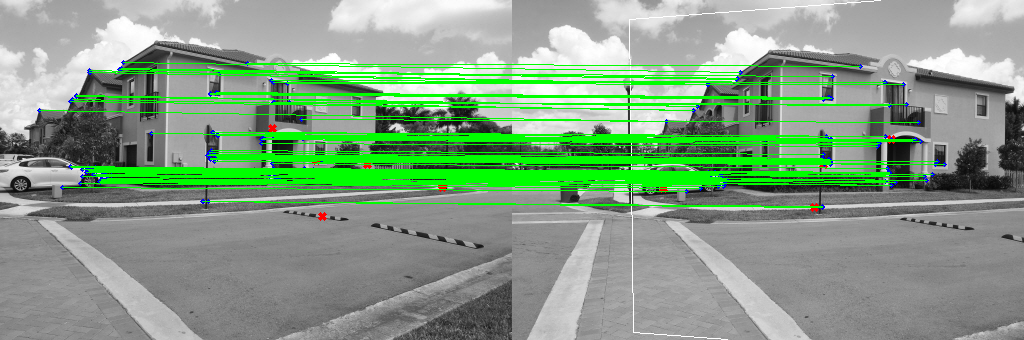

In [ ]:
vis = explore_match(img1, img2, kp_pairs, status, H)
cv2_imshow(vis)

# 4-2

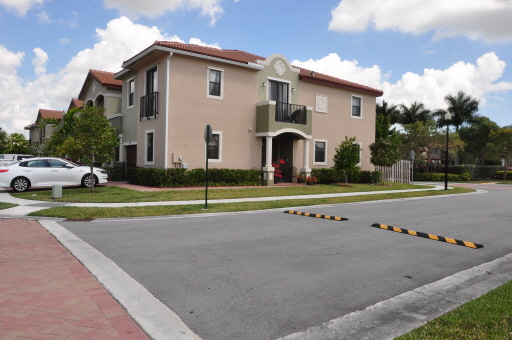

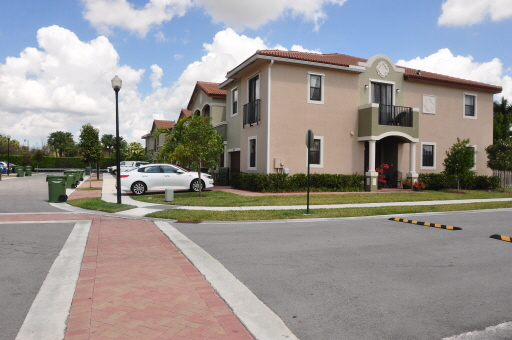

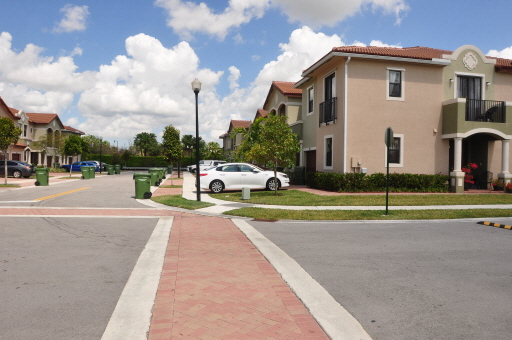

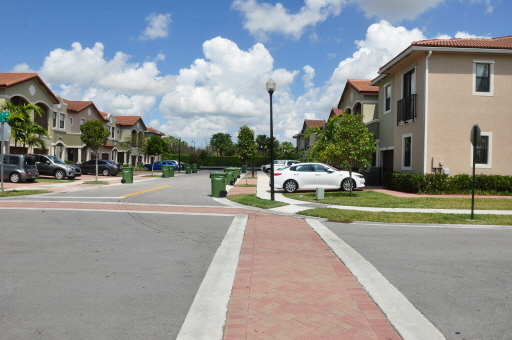

In [ ]:
img_names = ["img1.jpg", "img2.jpg", "img3.jpg", "img4.jpg"]
imgs = []
for img_name in img_names:
    img = cv.imread(cv.samples.findFile(img_name))
    imgs.append(img)
    cv2_imshow(img)

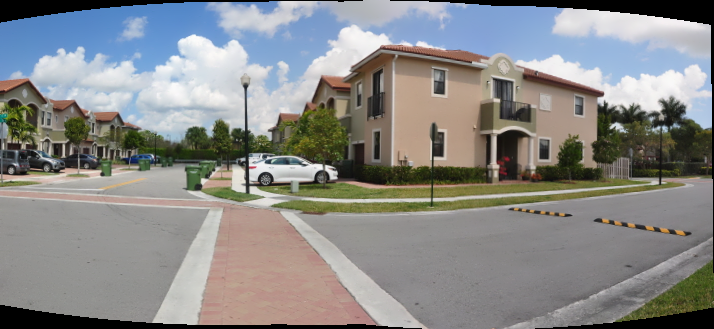

In [ ]:
stitcher = cv.Stitcher.create(cv.Stitcher_PANORAMA)
status, pano = stitcher.stitch(imgs)
cv2_imshow(pano)